<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [19]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [20]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [21]:
# Creating and storing the embeddings
from openai import OpenAI
import os

client=OpenAI(api_key = os.getenv("OPENAI_API_KEY"))

review_texts=reviews['Review Text'].dropna().tolist()

response=client.embeddings.create(
    model = "text-embedding-3-small",
    input = review_texts
)
response_dict = response.model_dump()
embeddings = [item['embedding'] for item in response_dict['data']]

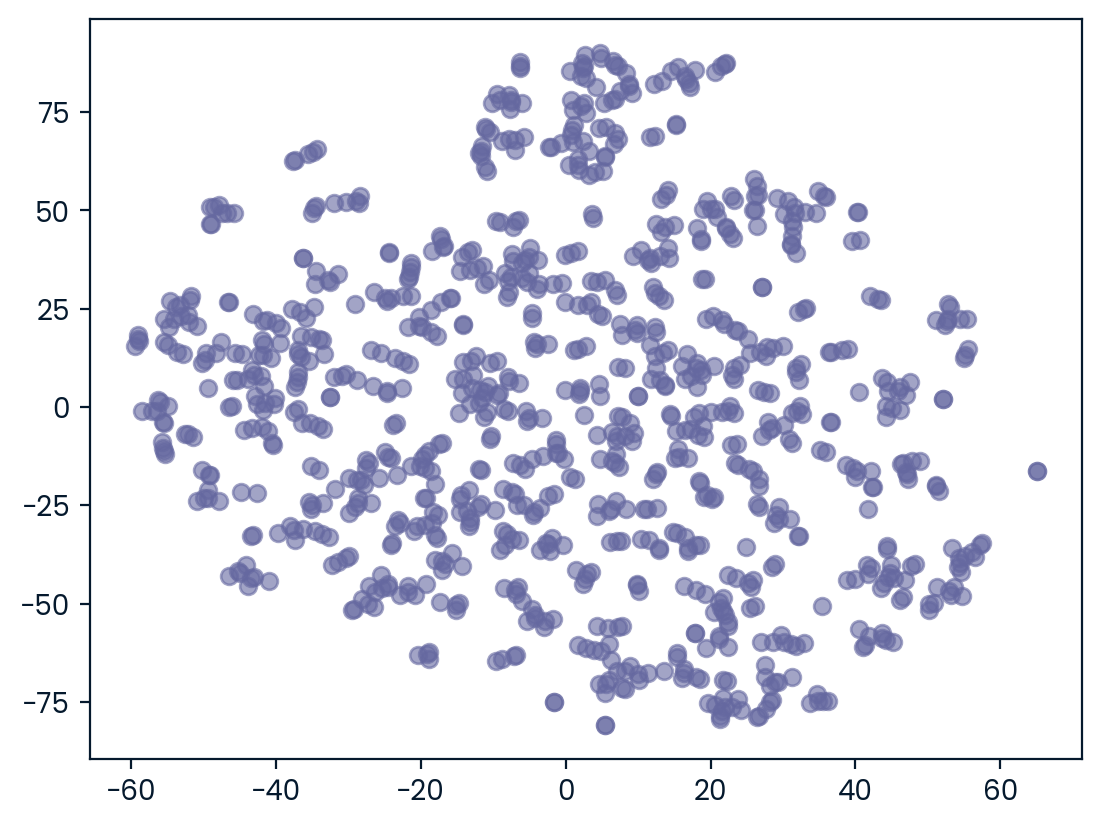

In [22]:
# Dimension reduction and visualization
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Dimension Reduction
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

# Visualization
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
plt.show()

In [23]:
from scipy.spatial import distance
import numpy as np

# Defining a custom create_embeddings function
def create_embeddings(texts):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=texts 
    )
    response_dict = response.model_dump()
    return [data['embedding'] for data in response_dict['data']]

# Identifying Reviews
search_text1 = "quality"
search_embedding1 = create_embeddings([search_text1])[0]
embeddings_np = np.array(embeddings)
distances = distance.cdist([search_embedding1], embeddings_np, metric='cosine')[0]
min_dist_ind = np.argmin(distances)

review_texts = reviews['Review Text'].dropna().reset_index(drop=True)
review_texts.iloc[min_dist_ind]

'This top is soo pretty with a cool edge.\nit looks and feels like really good quality.'

In [24]:
# Finding similar reviews
import os
import chromadb
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

try:
    review_texts = review_texts.tolist()
except AttributeError:
    pass  

client = chromadb.PersistentClient(path="path/to/save/to")

embedding_function = OpenAIEmbeddingFunction(
    model_name="text-embedding-3-small",
    api_key=os.getenv("OPENAI_API_KEY")
)

collection = client.create_collection(
    name="my_collection",
    embedding_function=embedding_function,
    get_or_create=True
)

# Add review texts to the collection if not already present
if collection.count() == 0:
    collection.add(
        ids=[str(i) for i in range(len(review_texts))],
        documents=review_texts
    )

# Querying the reviews
result = collection.query(
    query_texts=["Absolutely wonderful - silky and sexy and comfortable"],
    n_results=3
)

# Extract the most similar reviews
most_similar_reviews = [result['documents'][0][i] for i in range(len(result['documents'][0]))]
most_similar_reviews

['Absolutely wonderful - silky and sexy and comfortable',
 'Very comfortable and versatile. got lots of compliments.',
 'This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.']